<a href="https://colab.research.google.com/github/AbderrahmenHachicha/CardioDiffusion/blob/main/notebooks/01_data_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTE: This notebook requires Google Drive access.
# Dataset: MIT-BIH Arrhythmia Database
# Drive structure: /MyDrive/Projet PFA/1_Data/raw/archive/
# Download dataset from: https://www.kaggle.com/datasets/mondejar/mitbih-database

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

path = '/content/drive/MyDrive/Projet PFA/1_Data/raw/archive/'
files = sorted(os.listdir(path))

print(f"Total files: {len(files)}")
print(files[:10])

Total files: 96
['100.csv', '100annotations.txt', '101.csv', '101annotations.txt', '102.csv', '102annotations.txt', '103.csv', '103annotations.txt', '104.csv', '104annotations.txt']


In [ ]:
import pandas as pd
df1 = pd.read_csv('/content/drive/MyDrive/Projet PFA/1_Data/raw/archive/100.csv')
df1.columns = df1.columns.str.replace("'", "").str.strip()
print("First 10 rows:")
print(df1.head(10))

print(f"\nShape: {df1.shape}")
print(f"Columns: {df1.columns.tolist()}")

First 10 rows:
   sample #  MLII    V5
0         0   995  1011
1         1   995  1011
2         2   995  1011
3         3   995  1011
4         4   995  1011
5         5   995  1011
6         6   995  1011
7         7   995  1011
8         8  1000  1008
9         9   997  1008

Shape: (650000, 3)
Columns: ['sample #', 'MLII', 'V5']


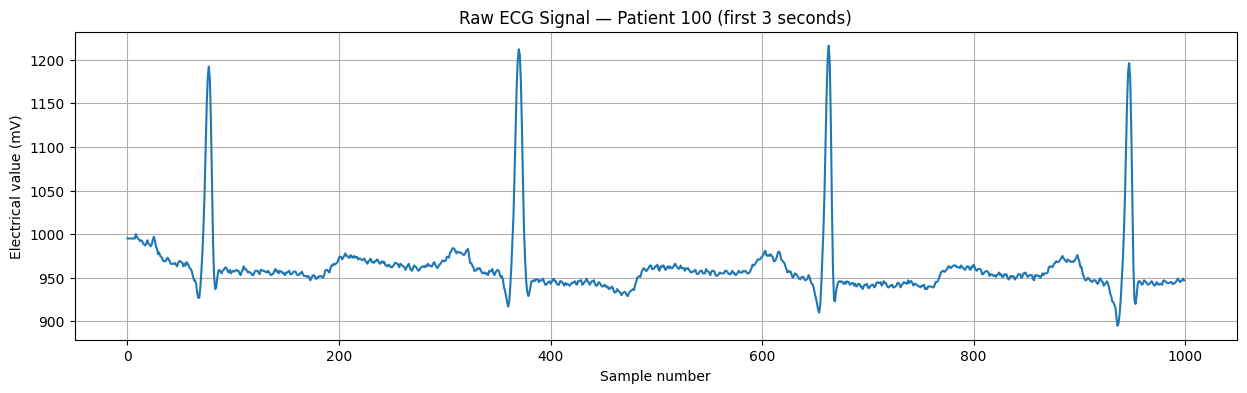

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
plt.plot(df1["MLII"][:1000])
plt.title("Raw ECG Signal — Patient 100 (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Electrical value (mV)")
plt.grid(True)
plt.show()

In [ ]:
# Read the labels for patient 100
with open('/content/drive/MyDrive/Projet PFA/1_Data/raw/archive/100annotations.txt', 'r') as f:
    content = f.read()

print(content[:500])  # print first 500 characters

      Time   Sample #  Type  Sub Chan  Num	Aux
    0:00.050       18     +    0    0    0	(N
    0:00.214       77     N    0    0    0
    0:01.028      370     N    0    0    0
    0:01.839      662     N    0    0    0
    0:02.628      946     N    0    0    0
    0:03.419     1231     N    0    0    0
    0:04.208     1515     N    0    0    0
    0:05.025     1809     N    0    0    0
    0:05.678     2044     A    0    0    0
    0:06.672     2402     N    0    0    0
    0:07.517     270


In [ ]:
def parse_annotations(filepath):
    annotations = []

    with open(filepath, 'r') as f:
        lines = f.readlines()

    for line in lines[1:]:  # skip header
        parts = line.strip().split()
        if len(parts) >= 3:
            sample = int(parts[1])
            beat_type = parts[2]
            annotations.append({'sample': sample, 'type': beat_type})

    return pd.DataFrame(annotations)

ann = parse_annotations('/content/drive/MyDrive/Projet PFA/1_Data/raw/archive/100annotations.txt')
print(ann.head(10))
print(ann['type'].value_counts())


   sample type
0      18    +
1      77    N
2     370    N
3     662    N
4     946    N
5    1231    N
6    1515    N
7    1809    N
8    2044    A
9    2402    N
type
N    2239
A      33
+       1
V       1
Name: count, dtype: int64


In [ ]:
def segment_beat(signal , peak):
  if peak - 93 <0:
    return None
  elif peak + 93 >len(signal):
    return None
  else:
    return signal.iloc[peak-93 : peak+94, 1]

In [ ]:
def process_patient(signal, ann, patient_id):
    rows = []
    for _, row in ann.iterrows():
        peak = row['sample']
        label = row['type']
        if label == '+':
            continue
        segment = segment_beat(signal, peak)
        if segment is not None:
            rows.append(segment.tolist() + [label] + [patient_id])

    cols = [f"segment_{i}" for i in range(187)] + ["label", "patient"]
    return pd.DataFrame(rows, columns=cols)

In [ ]:
df_100 = process_patient(df, ann, 100)
print(df_100.shape)
print(df_100.head())

(2271, 189)
   segment_0  segment_1  segment_2  segment_3  segment_4  segment_5  \
0        961        962        963        963        962        964   
1        954        954        956        958        955        955   
2        953        953        953        949        947        953   
3        948        952        952        955        955        954   
4        958        958        958        956        956        956   

   segment_6  segment_7  segment_8  segment_9  ...  segment_179  segment_180  \
0        963        966        964        964  ...          938          938   
1        953        954        956        958  ...          940          940   
2        952        953        952        952  ...          949          951   
3        953        955        958        958  ...          934          935   
4        959        959        959        955  ...          939          942   

   segment_181  segment_182  segment_183  segment_184  segment_185  \
0         

In [ ]:
def process_all_patients():
  all_patients = []
  for file_name in files:
    file_path = os.path.join(path, file_name)
    if not file_name.endswith(".csv"):
      continue
    signal_path = os.path.join(path, file_name)
    patient_id=int(file_name.split(".")[0])
    ann_path = os.path.join(path, f"{patient_id}annotations.txt")
    signals = pd.read_csv(signal_path)
    signals.columns = signals.columns.str.replace("'", "").str.strip()
    ann = parse_annotations(ann_path)
    df_patient = process_patient(signals, ann, patient_id)
    all_patients.append(df_patient)

  return pd.concat(all_patients, ignore_index=True)

final_df = process_all_patients()
final_df.to_csv('/content/drive/MyDrive/Projet PFA/1_Data/processed/ecg_segments.csv', index=False)
print(f"✅ Done! Shape: {final_df.shape}")

✅ Done! Shape: (111328, 189)
